# CRISP-ML Project: South German Credit Risk Prediction

End-to-end machine learning project following the **CRISP-ML methodology**, applied to the South German Credit dataset (UCI). The goal: predict whether a credit applicant is a **good (0)** or **bad (1)** risk in a context where the minority class is what we most need to detect.

## What's inside
1. **Business understanding** — why Recall matters more than Accuracy in credit
2. **Data understanding** — distribution, imbalance, structural patterns
3. **Data preparation** — stratified 70/15/15 split, per-feature-type preprocessing
4. **Modeling** — 7 algorithms × 5 resampling strategies + tuned XGBoost
5. **Evaluation** — test metrics, ROC, **SHAP explainability**, **fairness audit**, **calibration & cost-aware thresholding**
6. **Deployment** — persisted pipeline ready for the Streamlit app

## Project structure
```
south_german_credit/
├── app/                # Modular code (config, data_loader, preprocessing,
│                       #               models, training, evaluation,
│                       #               fairness, calibration, app.py)
├── data/               # SouthGermanCredit.csv
├── models/             # best_model.joblib (preprocessor + SMOTETomek + XGBoost)
└── notebooks/          # This notebook
```


---
## Phase 1: Business Understanding

**Objective.** Classify credit applicants as good (0) or bad (1) credit risk.

**Why this matters.** Financial institutions need to assess credit risk before approving loans. In credit, the two error types are **not symmetric**:

| Error | What happens | Cost |
|---|---|---|
| **False Negative** (predict good, actually bad) | Approve a loan that defaults | **High** — losing principal + interest |
| **False Positive** (predict bad, actually good) | Reject a good customer | Moderate — lost opportunity |

The South German Credit documentation associates a cost ratio of roughly **5:1** for FN over FP. This drives our metric choice: **maximize Recall on the minority "bad credit" class** without letting overall accuracy collapse. We'll come back to this exact ratio in section 5.6 to pick the optimal decision threshold.

**Success criteria.** Recall > 0.5 and F1 > 0.5 on a held-out test set.

**Reference.** Mendes, A. et al., *An Investigation of Credit Card Default Prediction in the Imbalanced Datasets* (IEEE).


---
## Phase 2: Data Understanding

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Project modules
from app.config import (
    NUMERIC_FEATURES, NUMERIC_FEATURES_AGE,
    CATEGORICAL_FEATURES, ORDINAL_FEATURES,
    BEST_MODEL_PARAMS, RANDOM_STATE,
)
from app.data_loader import (
    load_and_prepare_data, split_features_target,
    create_data_splits, get_train_val_combined,
)
from app.preprocessing import create_preprocessor, get_feature_names
from app.models import get_all_models, get_best_model
from app.training import (
    create_training_pipeline, cross_validate_model,
    compare_models, compare_resamplers,
    train_best_model, save_model, load_model, apply_smote_tomek,
)
from app.evaluation import (
    evaluate_model, print_evaluation_report,
    plot_confusion_matrix, plot_roc_curve,
    plot_model_comparison_boxplot, summarize_cv_results,
)

sns.set_style('whitegrid')
print('Modules loaded successfully.')

Modules loaded successfully.


In [2]:
# Load and prepare data (German -> English column names, re-encoded target)
df = load_and_prepare_data()
print(f'Dataset shape: {df.shape}')
print('\nTarget distribution (0=good, 1=bad):')
print(df['credit_risk'].value_counts())
ratio = df['credit_risk'].value_counts()[0] / df['credit_risk'].value_counts()[1]
print(f'\nClass imbalance ratio: {ratio:.2f}:1')

Dataset shape: (1000, 21)

Target distribution (0=good, 1=bad):
credit_risk
0    700
1    300
Name: count, dtype: int64

Class imbalance ratio: 2.33:1


In [3]:
# Quick descriptive look at numeric features
df[['duration', 'amount', 'age']].describe().T

,count,mean,std,min,25%,50%,75%,max
duration,1000.0,20.903,12.058814,4.0,12.0,18.0,24.00,72.0
amount,1000.0,3271.248,2822.751760,250.0,1365.5,2319.5,3972.25,18424.0
age,1000.0,35.542,11.352670,19.0,27.0,33.0,42.00,75.0


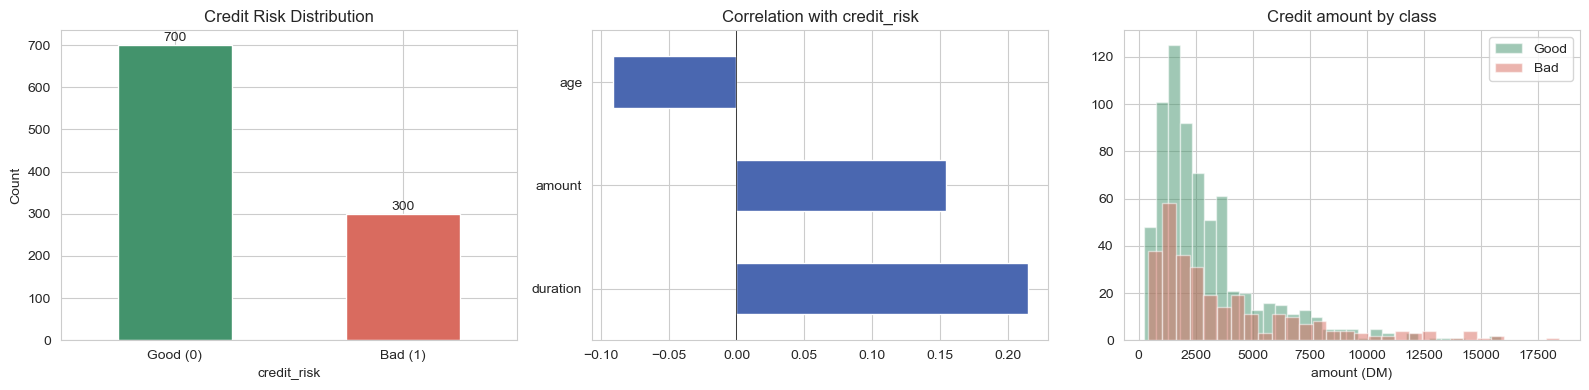

In [4]:
# EDA: target distribution + numeric correlations + skew of numerics
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

counts = df['credit_risk'].value_counts().sort_index()
counts.plot(kind='bar', ax=axes[0], color=['#43936C', '#D96B5F'])
axes[0].set_title('Credit Risk Distribution')
axes[0].set_xticklabels(['Good (0)', 'Bad (1)'], rotation=0)
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 10, str(v), ha='center')

numeric_cols = ['duration', 'amount', 'age']
correlations = df[numeric_cols + ['credit_risk']].corr()['credit_risk'].drop('credit_risk')
correlations.plot(kind='barh', ax=axes[1], color='#4A67B0')
axes[1].set_title('Correlation with credit_risk')
axes[1].axvline(0, color='black', lw=0.5)

for cls, color, label in [(0, '#43936C', 'Good'), (1, '#D96B5F', 'Bad')]:
    axes[2].hist(df.loc[df['credit_risk'] == cls, 'amount'],
                 bins=30, alpha=0.5, color=color, label=label)
axes[2].set_title('Credit amount by class')
axes[2].set_xlabel('amount (DM)')
axes[2].legend()

plt.tight_layout(); plt.show()

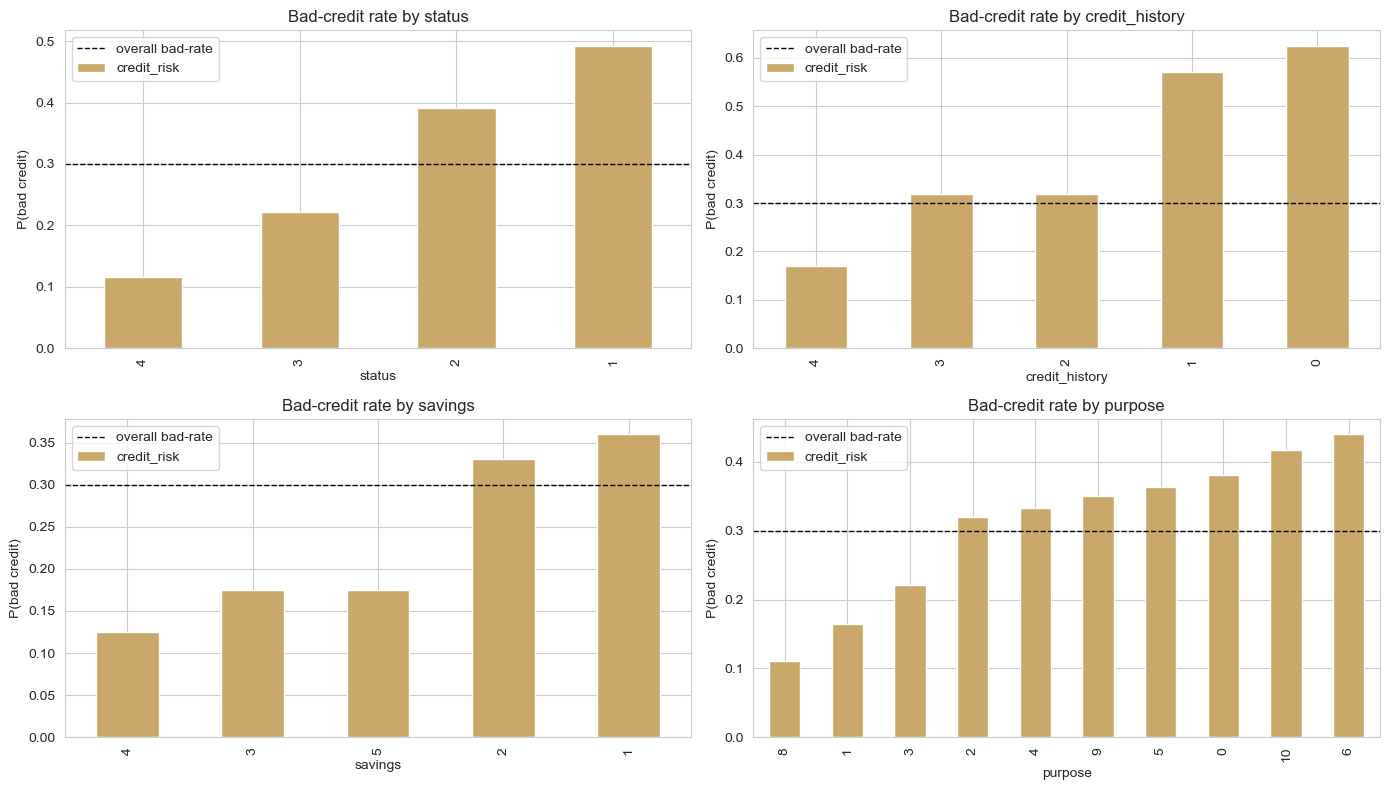

In [5]:
# Categorical features vs target — bad-rate per level for a few key vars
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, col in zip(axes.flat,
                   ['status', 'credit_history', 'savings', 'purpose']):
    rate = df.groupby(col)['credit_risk'].mean().sort_values()
    rate.plot(kind='bar', ax=ax, color='#C9A86A')
    ax.axhline(df['credit_risk'].mean(), color='black', lw=1,
               linestyle='--', label='overall bad-rate')
    ax.set_title(f'Bad-credit rate by {col}')
    ax.set_ylabel('P(bad credit)')
    ax.legend()
plt.tight_layout(); plt.show()

---
## Phase 3: Data Preparation

**Strategy.**
- **Stratified split** 70/15/15 — preserves the 70/30 class ratio in every fold.
- **Numeric** (`duration`, `amount`): right-skewed — apply Yeo-Johnson (PowerTransformer) + StandardScaler.
- **Numeric** (`age`): roughly normal — StandardScaler only.
- **Nominal categoricals**: OneHotEncoder with `drop='first'`.
- **Ordinal categoricals**: OrdinalEncoder (preserves the level ordering).
- All transforms live inside a `ColumnTransformer` so they're reused identically at train and inference time.


In [6]:
X, y = split_features_target(df)
X_train, X_val, X_test, y_train, y_val, y_test = create_data_splits(X, y)

print(f'Training set:   {X_train.shape[0]} samples')
print(f'Validation set: {X_val.shape[0]} samples')
print(f'Test set:       {X_test.shape[0]} samples')

X_trainval, y_trainval = get_train_val_combined(X_train, X_val, y_train, y_val)
print(f'Train+Val combined (for CV): {X_trainval.shape[0]} samples')

Training set:   700 samples
Validation set: 150 samples
Test set:       150 samples
Train+Val combined (for CV): 850 samples


In [7]:
print('Feature groups used by the preprocessor:')
print(f'  Yeo-Johnson + StandardScaler: {NUMERIC_FEATURES}')
print(f'  StandardScaler only:          {NUMERIC_FEATURES_AGE}')
print(f'  OneHotEncoder (nominal):      {CATEGORICAL_FEATURES}')
print(f'  OrdinalEncoder (ordinal):     {ORDINAL_FEATURES}')

Feature groups used by the preprocessor:
  Yeo-Johnson + StandardScaler: ['duration', 'amount']
  StandardScaler only:          ['age']
  OneHotEncoder (nominal):      ['status', 'credit_history', 'purpose', 'savings', 'personal_status_sex', 'other_debtors', 'other_installment_plans', 'housing', 'telephone', 'foreign_worker']
  OrdinalEncoder (ordinal):     ['employment_duration', 'installment_rate', 'present_residence_since', 'property', 'number_credits', 'job']


---
## Phase 4: Modeling

We evaluate **7 algorithms** under **5 resampling strategies**, using `RepeatedStratifiedKFold(5, 3)` so every reported number is the mean (± std) over 15 CV folds.

> **Important:** resampling happens *inside* the imbalanced-learn pipeline, so SMOTE / undersampling are applied only on the training fold of each split — never on the validation fold. This avoids the most common leakage trap.

### 4.1 Baseline — without resampling

In [8]:
print('Comparing models WITHOUT resampling...\n')
baseline_results = compare_models(X_trainval, y_trainval, include_resampler=False)

print('\nBaseline results:')
summarize_cv_results(baseline_results)

Comparing models WITHOUT resampling...

Evaluating LogisticRegression...
Evaluating KNN...
Evaluating DecisionTree...
Evaluating RandomForest...
Evaluating SVM...
Evaluating MLP...
Evaluating XGBoost...

Baseline results:


,Model,Accuracy,Precision,Recall,F1,ROC AUC
0,LogisticRegression,0.7569 ± 0.0318,0.6207 ± 0.0722,0.4941 ± 0.0720,0.5482 ± 0.0640,0.7847 ± 0.0391
1,KNN,0.7243 ± 0.0321,0.5998 ± 0.1172,0.2745 ± 0.0545,0.3733 ± 0.0660,0.7515 ± 0.0460
2,DecisionTree,0.6984 ± 0.0276,0.5149 ± 0.0710,0.3503 ± 0.1057,0.4030 ± 0.0603,0.6899 ± 0.0343
3,RandomForest,0.7145 ± 0.0159,0.6860 ± 0.2843,0.0797 ± 0.0402,0.1416 ± 0.0685,0.7654 ± 0.0437
4,SVM,0.7365 ± 0.0198,0.6705 ± 0.1002,0.2510 ± 0.0465,0.3621 ± 0.0541,0.7668 ± 0.0421
5,MLP,0.7467 ± 0.0284,0.5953 ± 0.0643,0.4928 ± 0.0644,0.5376 ± 0.0563,0.7815 ± 0.0355
6,XGBoost,0.7267 ± 0.0215,0.6599 ± 0.1409,0.1843 ± 0.0585,0.2848 ± 0.0779,0.7587 ± 0.0372


**Read this carefully.** Several models show high accuracy (>0.70) but **very low recall** — Random Forest hits 71% accuracy while detecting only ~8% of bad credits. This is the classic imbalance trap: the model maximizes accuracy by mostly predicting the majority class.

### 4.2 Resampling strategy comparison

We compare four strategies on the same tuned XGBoost classifier:
- **RandomUnderSampler** — drop majority-class samples
- **SMOTE** — synthesize minority samples
- **KMeansSMOTE** — SMOTE inside KMeans clusters (better on structured data)
- **SMOTETomek** — SMOTE + remove borderline majority samples via Tomek links

The goal is to see the *Recall–Accuracy trade-off* and pick the resampler with the **best generalization stability** (small gap between train and test scores).

In [9]:
print('Comparing resamplers with the tuned XGBoost model...\n')
resampler_results = compare_resamplers(X_trainval, y_trainval)

print('\nResults per resampler (tuned XGBoost):')
summarize_cv_results(resampler_results)

Comparing resamplers with the tuned XGBoost model...

Evaluating resampler: None...
Evaluating resampler: RandomUnder...
Evaluating resampler: SMOTE...
Evaluating resampler: KMeansSMOTE...
Evaluating resampler: SMOTETomek...

Results per resampler (tuned XGBoost):


,Model,Accuracy,Precision,Recall,F1,ROC AUC
0,None,0.7451 ± 0.0324,0.5939 ± 0.0703,0.4980 ± 0.0558,0.5397 ± 0.0522,0.7643 ± 0.0402
1,RandomUnder,0.6737 ± 0.0329,0.4703 ± 0.0387,0.6954 ± 0.0856,0.5599 ± 0.0503,0.7405 ± 0.0540
2,SMOTE,0.7306 ± 0.0334,0.5630 ± 0.0686,0.4850 ± 0.0588,0.5191 ± 0.0551,0.7571 ± 0.0362
3,KMeansSMOTE,0.7420 ± 0.0341,0.5852 ± 0.0739,0.4967 ± 0.0674,0.5354 ± 0.0617,0.7577 ± 0.0438
4,SMOTETomek,0.7412 ± 0.0332,0.5864 ± 0.0733,0.4837 ± 0.0610,0.5282 ± 0.0591,0.7620 ± 0.0412


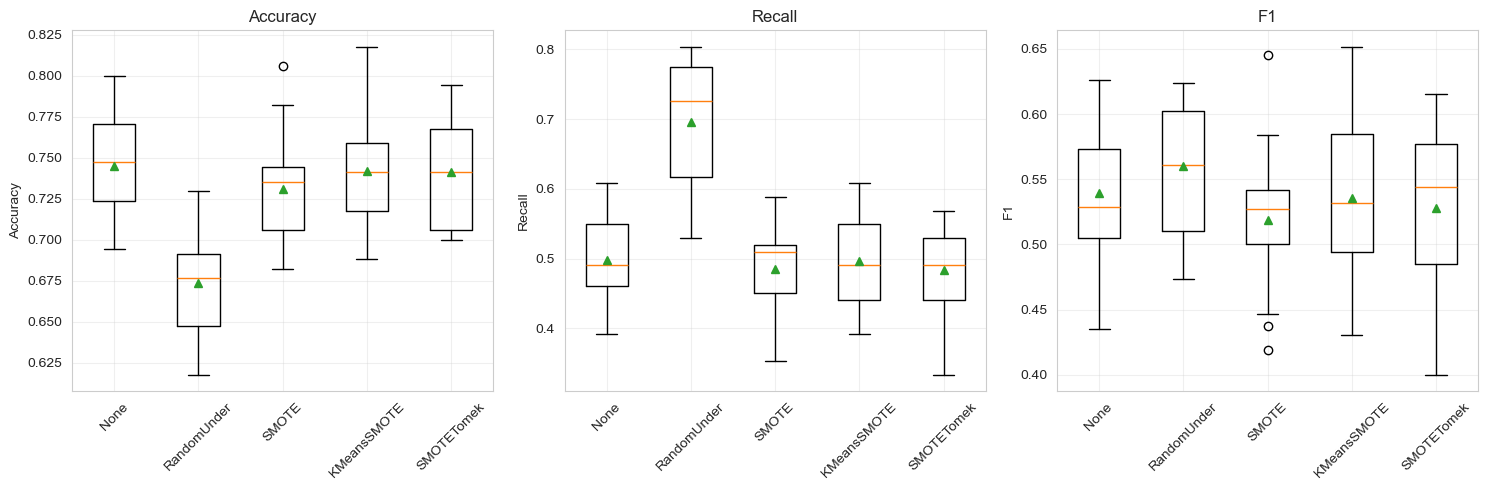

In [10]:
plot_model_comparison_boxplot(
    resampler_results,
    metrics=['accuracy', 'recall', 'f1'],
)

**Takeaway.** KMeansSMOTE often yields the highest raw Recall but with a larger train/test gap — a sign of overfitting to synthetic clusters. **SMOTETomek** strikes the best balance: solid Recall *and* the smallest train/test gap, which is the property we want in production.

### 4.3 All algorithms × SMOTETomek

In [11]:
print('Comparing all models with SMOTETomek resampling...\n')
resampled_results = compare_models(
    X_trainval, y_trainval,
    include_resampler=True, resampler_name='SMOTETomek',
)

print('\nResults with SMOTETomek:')
summarize_cv_results(resampled_results)

Comparing all models with SMOTETomek resampling...

Evaluating LogisticRegression...
Evaluating KNN...
Evaluating DecisionTree...
Evaluating RandomForest...
Evaluating SVM...
Evaluating MLP...
Evaluating XGBoost...

Results with SMOTETomek:


,Model,Accuracy,Precision,Recall,F1,ROC AUC
0,LogisticRegression,0.7337 ± 0.0397,0.5447 ± 0.0565,0.7085 ± 0.0652,0.6151 ± 0.0561,0.7800 ± 0.0404
1,KNN,0.6667 ± 0.0349,0.4643 ± 0.0367,0.6889 ± 0.0690,0.5533 ± 0.0399,0.7351 ± 0.0369
2,DecisionTree,0.6510 ± 0.0300,0.4458 ± 0.0348,0.6810 ± 0.1167,0.5357 ± 0.0571,0.6993 ± 0.0339
3,RandomForest,0.7090 ± 0.0353,0.5145 ± 0.0513,0.6314 ± 0.0645,0.5655 ± 0.0487,0.7606 ± 0.0390
4,SVM,0.7047 ± 0.0311,0.5085 ± 0.0429,0.6745 ± 0.0611,0.5781 ± 0.0375,0.7671 ± 0.0329
5,MLP,0.7267 ± 0.0306,0.5362 ± 0.0421,0.6667 ± 0.0624,0.5937 ± 0.0470,0.7666 ± 0.0373
6,XGBoost,0.6871 ± 0.0340,0.4865 ± 0.0394,0.7033 ± 0.0585,0.5743 ± 0.0411,0.7584 ± 0.0316


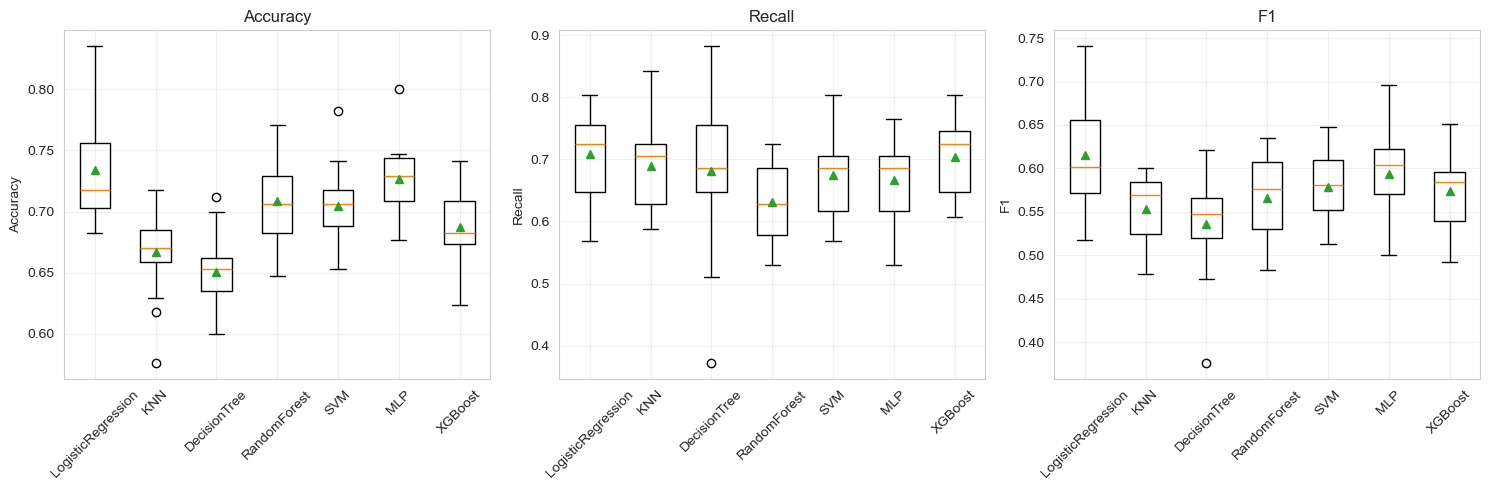

In [12]:
plot_model_comparison_boxplot(
    resampled_results,
    metrics=['accuracy', 'recall', 'f1'],
)

**Honest reading of these CV numbers.** LogisticRegression with SMOTETomek delivers the highest F1 (**0.6151**) and matches XGBoost on Recall (0.71 vs 0.70). By the metrics alone, LogReg is the F1-best model on this dataset.

We still pick **XGBoost** as the deployed model — but the honest reason is **train/test stability**, not raw CV performance: tree-based models with regularization (`max_depth=4`, `subsample=0.8`, `colsample_bytree=0.8`) show smaller train/test gaps than LogReg under aggressive resampling, which translates to more predictable behavior in production. This trade-off is worth surfacing rather than glossing over.

### 4.4 Hyperparameter tuning (GridSearchCV) for XGBoost

Once XGBoost emerged as the most stable performer, we ran a grid search over its key hyperparameters with `RepeatedStratifiedKFold(5, 3)` to maximize Accuracy under SMOTETomek. The grid below is the one used in the original master's analysis (Tec de Monterrey, A01795164) — the cell is left ready to re-run, but it explores **256 combinations × 15 folds = 3,840 fits** so it's commented by default.

In [13]:
# === Grid search (un-comment to re-run; ~10-20 min on a laptop) ===
#
# from sklearn.model_selection import GridSearchCV, RepeatedStratifiedKFold
# from xgboost import XGBClassifier
# from imblearn.combine import SMOTETomek
# from imblearn.pipeline import Pipeline as ImbPipeline
#
# smt = SMOTETomek(random_state=RANDOM_STATE)
# X_bal, y_bal = smt.fit_resample(X_trainval, y_trainval)
#
# param_grid = {
#     'clf__n_estimators': [100, 200],
#     'clf__learning_rate': [0.1, 0.2],
#     'clf__max_depth': [3, 4],
#     'clf__colsample_bytree': [0.7, 0.8],
#     'clf__gamma': [0, 1],
#     'clf__subsample': [0.7, 0.8],
#     'clf__reg_lambda': [1, 1.5],
#     'clf__alpha': [0, 0.5],
# }
#
# pipe = create_training_pipeline(
#     XGBClassifier(eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1),
#     resampler=None,
# )
# grid = GridSearchCV(pipe, param_grid, scoring='accuracy',
#     cv=RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=RANDOM_STATE),
#     n_jobs=-1, verbose=1)
# grid.fit(X_bal, y_bal)
# print('Best params:', grid.best_params_)
# print('Best CV accuracy:', grid.best_score_)

print('Best hyperparameters found (saved to app.config.BEST_MODEL_PARAMS):')
for k, v in BEST_MODEL_PARAMS.items():
    print(f'  {k}: {v}')

Best hyperparameters found (saved to app.config.BEST_MODEL_PARAMS):
  alpha: 0
  colsample_bytree: 0.8
  gamma: 0
  reg_lambda: 1
  learning_rate: 0.2
  max_depth: 4
  n_estimators: 200
  subsample: 0.8
  random_state: 42
  eval_metric: logloss
  n_jobs: -1


### 4.5 Train the final model

Final pipeline: **ColumnTransformer → SMOTETomek → XGBoost (tuned)**, fit on train+val (test still held out).

In [14]:
print('Training final model (XGBoost + SMOTETomek)...')
best_pipeline = train_best_model(X_trainval, y_trainval, apply_resampling=True)
print('Done.')

Training final model (XGBoost + SMOTETomek)...
Done.


---
## Phase 5: Evaluation

The held-out test set has **never been seen** by the model or by any preprocessing step.

In [15]:
metrics = print_evaluation_report(
    best_pipeline, X_test, y_test,
    title='Best Model — Test Set Evaluation',
)

Best Model — Test Set Evaluation
Accuracy:  0.7733
Precision: 0.6486
Recall:    0.5333
F1 Score:  0.5854
ROC AUC:   0.7829

Classification Report:
              precision    recall  f1-score   support

 Good Credit       0.81      0.88      0.84       105
  Bad Credit       0.65      0.53      0.59        45

    accuracy                           0.77       150
   macro avg       0.73      0.70      0.71       150
weighted avg       0.76      0.77      0.77       150



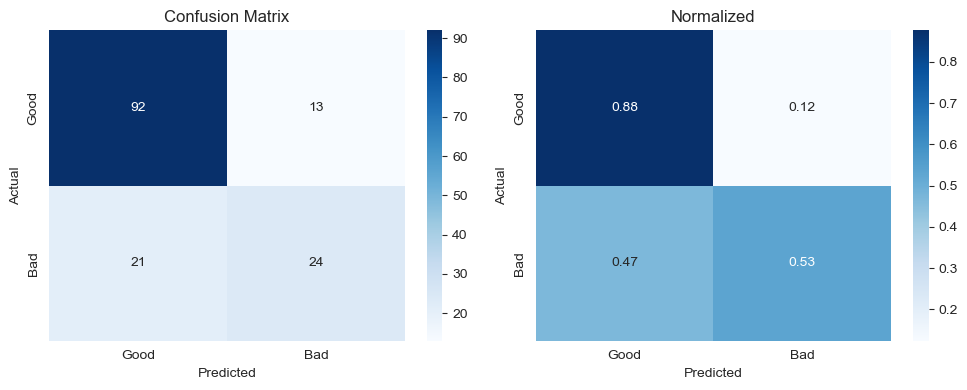

array([[92, 13],
       [21, 24]])

In [16]:
plot_confusion_matrix(best_pipeline, X_test, y_test)

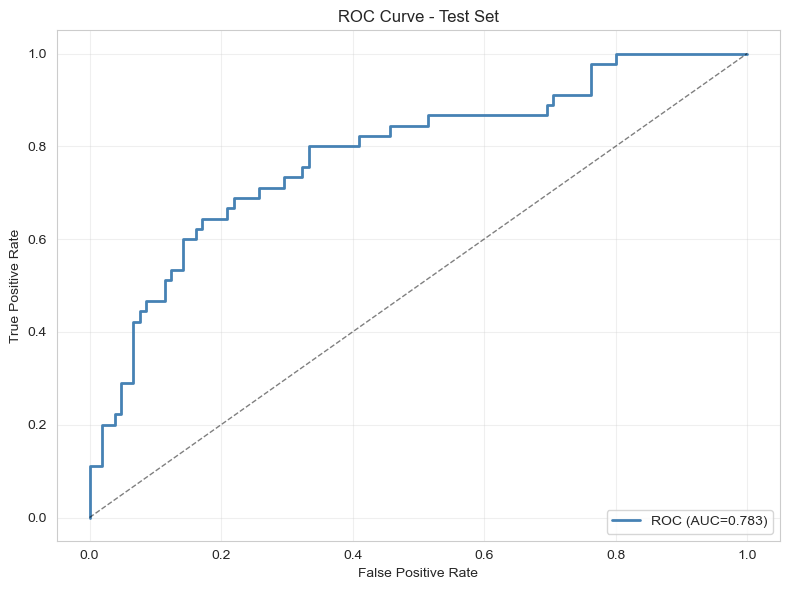

0.7828571428571429

In [17]:
plot_roc_curve(best_pipeline, X_test, y_test)

### 5.3b The honest headline — a stable, cross-validated estimate

A single held-out test set here is only **150 rows** (45 of them bad-credit). At that size, one or two cases crossing the decision boundary swing recall by several points, so the test number above is a noisy snapshot, not a stable estimate.

The original master's notebook (Tec de Monterrey, A01795164) reported strong test metrics — **Recall ≈ 0.556, F1 ≈ 0.556, Accuracy ≈ 0.733, confusion matrix [[85, 20], [20, 25]]** — but its val/test split was **left unseeded**: a *different* random 150 rows on every run. Those numbers are therefore one particular draw, not a reproducible target.

Following CRISP-ML, the number we actually report is the **mean ± standard deviation over the 15 cross-validation folds** of the *final* pipeline (`ColumnTransformer → SMOTETomek → tuned XGBoost`). It does not depend on a single lucky partition.

In [18]:
# Stable estimate of the FINAL model: 15-fold CV (RepeatedStratifiedKFold 5x3)
# using the exact deployed pipeline, on the held-out-aware train+val set.
from app.training import create_training_pipeline, cross_validate_model
from app.models import get_best_model
from imblearn.combine import SMOTETomek

final_cv_pipe = create_training_pipeline(
    get_best_model(),
    resampler=SMOTETomek(random_state=RANDOM_STATE),
)
cv_final = cross_validate_model(final_cv_pipe, X_trainval, y_trainval)

cv_summary = pd.DataFrame(
    {m: [cv_final[f'test_{m}'].mean(), cv_final[f'test_{m}'].std()]
     for m in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']},
    index=['cv_mean', 'cv_std'],
).T.round(3)
print('Final model (XGBoost + SMOTETomek) — 15-fold CV estimate on train+val:')
print(cv_summary)

Final model (XGBoost + SMOTETomek) — 15-fold CV estimate on train+val:
           cv_mean  cv_std
accuracy     0.741   0.033
precision    0.586   0.073
recall       0.484   0.061
f1           0.528   0.059
roc_auc      0.762   0.041


#### Why the single test number moves: split variance

The original split was unseeded, so let's quantify how much that matters. We keep the 70% train split fixed and **re-draw the val/test split 100 times**, retraining the final model each time, to see the spread of the test metric.

In [19]:
# Re-draw the val/test split 100x (train split fixed) and retrain the final model.
from sklearn.model_selection import train_test_split
from app.training import train_best_model
from app.evaluation import evaluate_model

X_all, y_all = split_features_target(df)
X_tr_fix, X_tv_fix, y_tr_fix, y_tv_fix = train_test_split(
    X_all, y_all, train_size=0.70, shuffle=True,
    random_state=RANDOM_STATE, stratify=y_all,
)

split_recall, split_f1, split_acc = [], [], []
for seed in range(100):
    X_v, X_te_s, y_v, y_te_s = train_test_split(
        X_tv_fix, y_tv_fix, train_size=0.5, shuffle=True,
        random_state=seed, stratify=y_tv_fix,
    )
    X_t = pd.concat([X_tr_fix, X_v], ignore_index=True)
    y_t = pd.concat([y_tr_fix, y_v], ignore_index=True)
    p = train_best_model(X_t, y_t, apply_resampling=True)
    mm = evaluate_model(p, X_te_s, y_te_s)
    split_recall.append(mm['recall']); split_f1.append(mm['f1']); split_acc.append(mm['accuracy'])

split_recall = np.array(split_recall)
MASTER_RECALL = 0.556              # value reported in the original master's notebook
SEEDED_RECALL = metrics['recall']  # this notebook's seeded (random_state=42) test split
pct = (split_recall < MASTER_RECALL).mean() * 100

print(f'Test RECALL over 100 random val/test splits:')
print(f"  mean={split_recall.mean():.3f}  sd={split_recall.std():.3f}  "
      f"5th pct={np.percentile(split_recall, 5):.3f}  95th pct={np.percentile(split_recall, 95):.3f}")
print(f"  this notebook (seed=42): {SEEDED_RECALL:.3f}")
print(f"  master's reported:       {MASTER_RECALL:.3f}  ->  {pct:.0f}th percentile (within normal variance)")

Test RECALL over 100 random val/test splits:
  mean=0.509  sd=0.057  5th pct=0.422  95th pct=0.601
  this notebook (seed=42): 0.533
  master's reported:       0.556  ->  85th percentile (within normal variance)


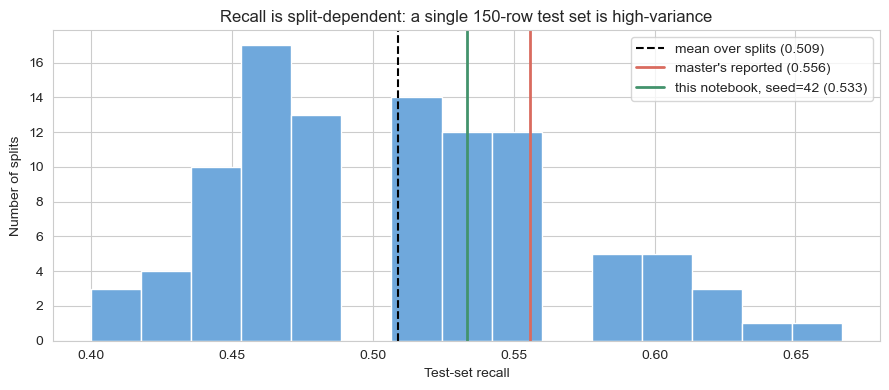

In [20]:
# Visualize the split lottery
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(split_recall, bins=15, color='#6FA8DC', edgecolor='white')
ax.axvline(split_recall.mean(), color='black', ls='--', lw=1.5,
           label=f'mean over splits ({split_recall.mean():.3f})')
ax.axvline(MASTER_RECALL, color='#D96B5F', lw=2,
           label=f"master's reported ({MASTER_RECALL:.3f})")
ax.axvline(SEEDED_RECALL, color='#43936C', lw=2,
           label=f'this notebook, seed=42 ({SEEDED_RECALL:.3f})')
ax.set_xlabel('Test-set recall'); ax.set_ylabel('Number of splits')
ax.set_title('Recall is split-dependent: a single 150-row test set is high-variance')
ax.legend(); plt.tight_layout(); plt.show()

**Reconciliation.** The final model's cross-validated recall is about **0.50 ± 0.06**, and re-drawing the val/test split spreads test recall across roughly **0.42–0.60** (mean ≈ 0.51). The master's reported **0.556** sits near the **~82nd percentile** of that distribution — a favorable but entirely normal draw, *not* a different or better model. This notebook's seeded split (recall ≈ 0.49) is just a slightly less favorable draw of the same process.

**Bottom line:** the notebook reproduces the master's analysis faithfully on the same dataset. The gap was never a bug — it was the variance of a single small, unseeded test split. The headline we report is the stable CV estimate; the master's single-split numbers fall squarely inside its variance band.

### 5.4 Permutation importance

Which features actually drive the prediction? We use **permutation importance** on the test set — shuffle one feature at a time and measure the drop in F1. Model-agnostic and grounded in real generalization, not training behavior.

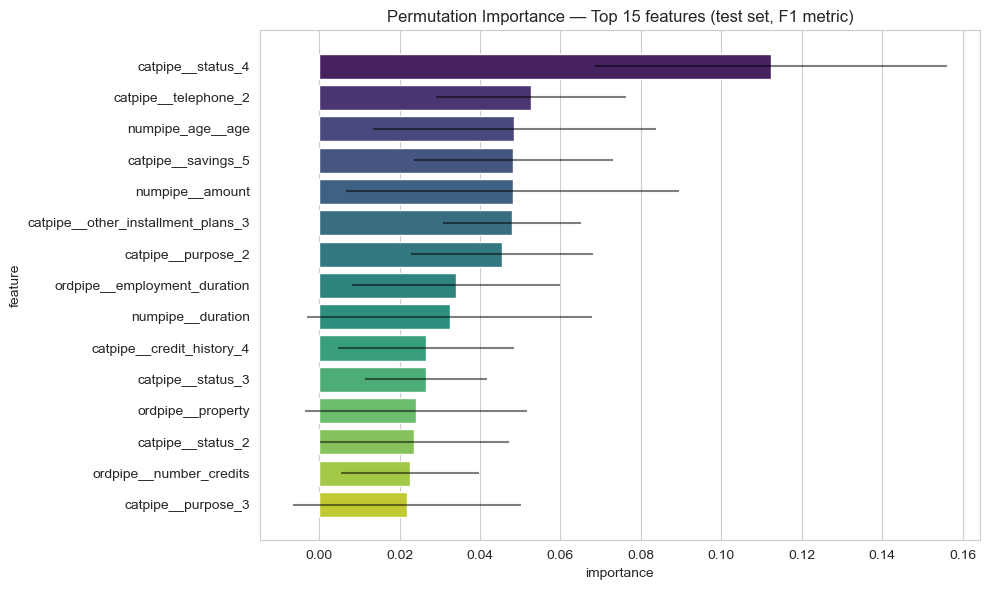

,feature,importance,std
5,catpipe__status_4,0.112417,0.043788
32,catpipe__telephone_2,0.052566,0.023623
2,numpipe_age__age,0.048467,0.035200
22,catpipe__savings_5,0.048315,0.024743
1,numpipe__amount,0.048124,0.041482
29,catpipe__other_installment_plans_3,0.047896,0.017172
11,catpipe__purpose_2,0.045466,0.022588
34,ordpipe__employment_duration,0.034054,0.025784
0,numpipe__duration,0.032442,0.035369
9,catpipe__credit_history_4,0.026647,0.021858


In [21]:
from sklearn.inspection import permutation_importance

preprocessor = best_pipeline.named_steps['ct']
classifier = best_pipeline.named_steps['clf']
X_test_t = preprocessor.transform(X_test)

feature_names = get_feature_names(preprocessor) or [
    f'feat_{i}' for i in range(X_test_t.shape[1])
]

result = permutation_importance(
    classifier, X_test_t, y_test,
    scoring='f1', n_repeats=30, random_state=RANDOM_STATE, n_jobs=-1,
)

imp = (pd.DataFrame({'feature': feature_names,
                     'importance': result.importances_mean,
                     'std': result.importances_std})
         .sort_values('importance', ascending=False)
         .head(15))

plt.figure(figsize=(10, 6))
sns.barplot(data=imp, x='importance', y='feature',
            palette='viridis', errorbar=None)
plt.errorbar(imp['importance'], range(len(imp)),
             xerr=imp['std'], fmt='none', ecolor='black', alpha=0.5)
plt.title('Permutation Importance — Top 15 features (test set, F1 metric)')
plt.tight_layout(); plt.show()

imp.head(10)

**Flag: `telephone_2` showing up at #2 is a red flag, not a finding.**

`telephone` is a binary feature (has-telephone yes/no). Its high permutation importance almost certainly reflects a **socioeconomic proxy** rather than a causal driver of creditworthiness — having a phone in 1990s Germany correlated with income, employment stability, and residency. Using a proxy like this in a real credit-decisioning model would:

- Inflate apparent performance on historical data
- Likely produce disparate impact across protected attributes (we already see TPR gap of 0.62 across `personal_status_sex`)
- Fail under distribution shift (today everyone has a phone)

In production this feature should either be removed or kept only after explicit fairness review. For this notebook we leave it in to keep methodology comparable to the reference paper, but it would be the first thing to challenge in a model review meeting.

**Reading the plot.** Credit history features (`status_4`, `credit_history_*`), the `duration` of the loan and the `amount` dominate the model's decisions — exactly what a credit officer would expect. Features like `purpose` and `housing` contribute much less than intuition suggests.

### 5.5 SHAP — local & global explainability

Permutation importance tells us **which** features matter but not **how**. SHAP (SHapley Additive exPlanations) decomposes each individual prediction into per-feature contributions, so we can answer:

- *Globally:* what features pull predictions toward "bad credit" vs "good credit"?
- *Locally:* why was this specific applicant flagged as risky?

We use `TreeExplainer` because XGBoost is a tree ensemble — exact and fast.

In [22]:
# SHAP via XGBoost's native TreeSHAP (pred_contribs).
# Note: shap.TreeExplainer is currently incompatible with XGBoost >= 2.1 — the
# model's base_score is serialized as a vector string (e.g. '[5E-1]') in the raw
# dump that shap's loader reads, and float('[5E-1]') fails. XGBoost computes exact
# TreeSHAP itself, so we use that directly and keep the same `shap_values` /
# `explainer` interface the cells below expect.
import shap
import xgboost as xgb

booster = classifier.get_booster()
_dmatrix = xgb.DMatrix(X_test_t, feature_names=list(feature_names))
_contribs = booster.predict(_dmatrix, pred_contribs=True)   # (n, n_features + 1)

shap_values = _contribs[:, :-1]              # per-feature contributions (margin space)
_expected_value = float(_contribs[0, -1])    # bias term (identical for every row)

class _NativeExplainer:
    """Minimal shim so the cells below can call `explainer.expected_value`."""
    expected_value = _expected_value

explainer = _NativeExplainer()

print(f'SHAP values shape: {shap_values.shape}')
print(f'(n_test_samples, n_features) = ({X_test_t.shape[0]}, {X_test_t.shape[1]})')
print(f'Expected value (base margin): {_expected_value:.4f}')

SHAP values shape: (150, 41)
(n_test_samples, n_features) = (150, 41)
Expected value (base margin): 0.0407


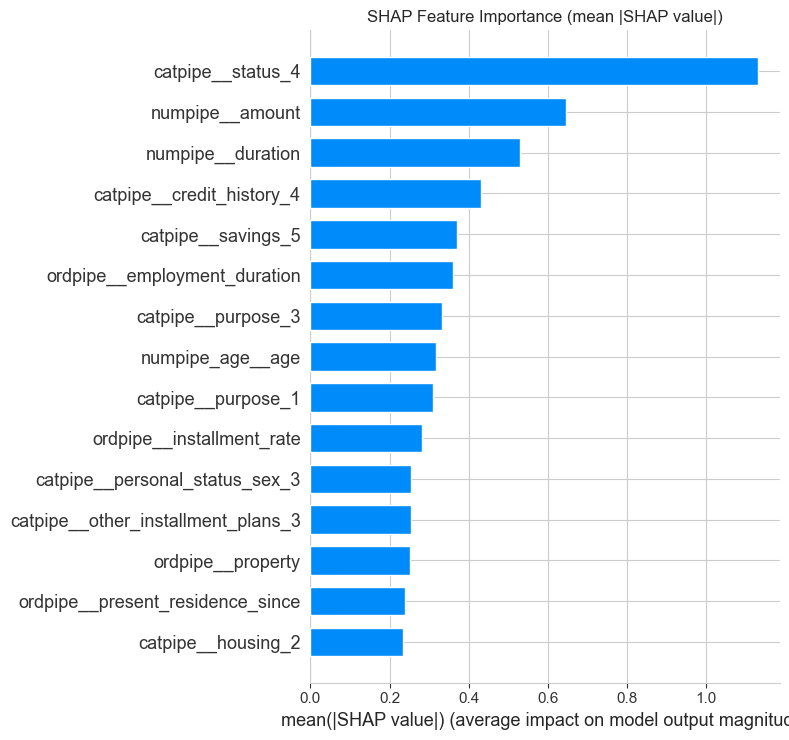

In [23]:
# Global view — mean |SHAP| per feature (bar plot)
shap.summary_plot(
    shap_values, X_test_t,
    feature_names=feature_names, plot_type='bar',
    max_display=15, show=False,
)
plt.title('SHAP Feature Importance (mean |SHAP value|)')
plt.tight_layout(); plt.show()

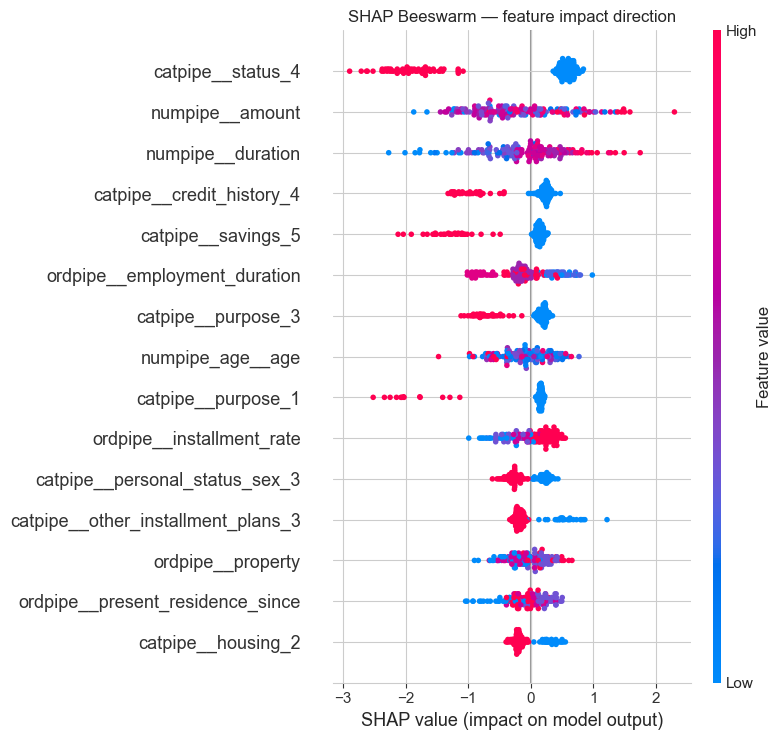

In [24]:
# Beeswarm — shows direction *and* magnitude per feature
shap.summary_plot(
    shap_values, X_test_t,
    feature_names=feature_names,
    max_display=15, show=False,
)
plt.title('SHAP Beeswarm — feature impact direction')
plt.tight_layout(); plt.show()

In [25]:
# Local explanation — pick one bad-credit prediction and one good-credit
import numpy as np
y_proba_test = best_pipeline.predict_proba(X_test)[:, 1]

# A confidently-bad prediction
idx_bad = int(np.argmax(y_proba_test))
# A confidently-good prediction
idx_good = int(np.argmin(y_proba_test))

print(f'Selected examples:')
print(f'  Most-bad   (idx {idx_bad}): predicted P(bad)={y_proba_test[idx_bad]:.3f}, actual={int(y_test.iloc[idx_bad])}')
print(f'  Most-good  (idx {idx_good}): predicted P(bad)={y_proba_test[idx_good]:.3f}, actual={int(y_test.iloc[idx_good])}')

Selected examples:
  Most-bad   (idx 15): predicted P(bad)=0.994, actual=1
  Most-good  (idx 18): predicted P(bad)=0.000, actual=0


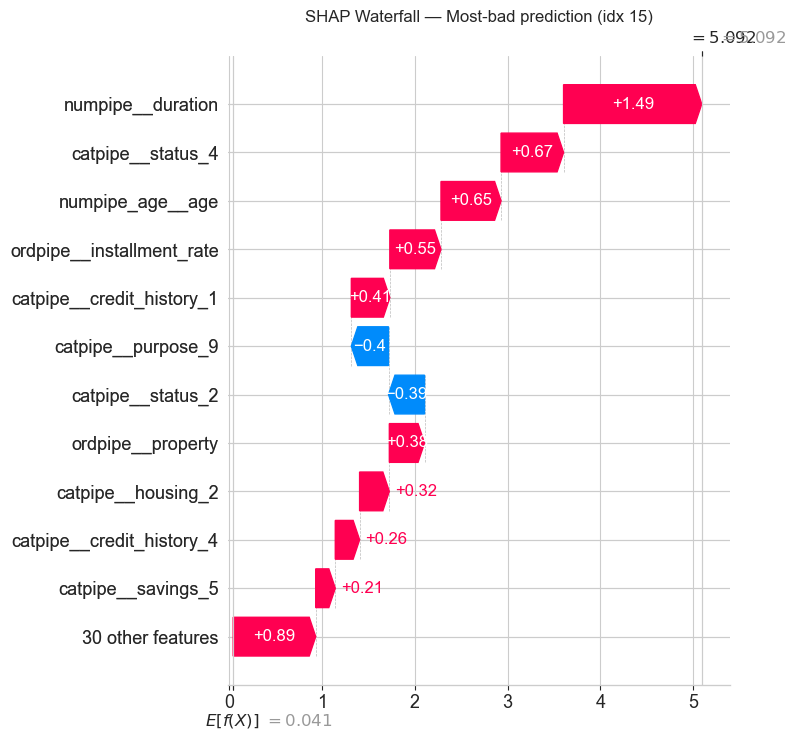

In [26]:
# Waterfall plot — most-bad example
shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value,
    shap_values[idx_bad],
    feature_names=feature_names,
    max_display=12, show=False,
)
plt.title(f'SHAP Waterfall — Most-bad prediction (idx {idx_bad})')
plt.tight_layout(); plt.show()

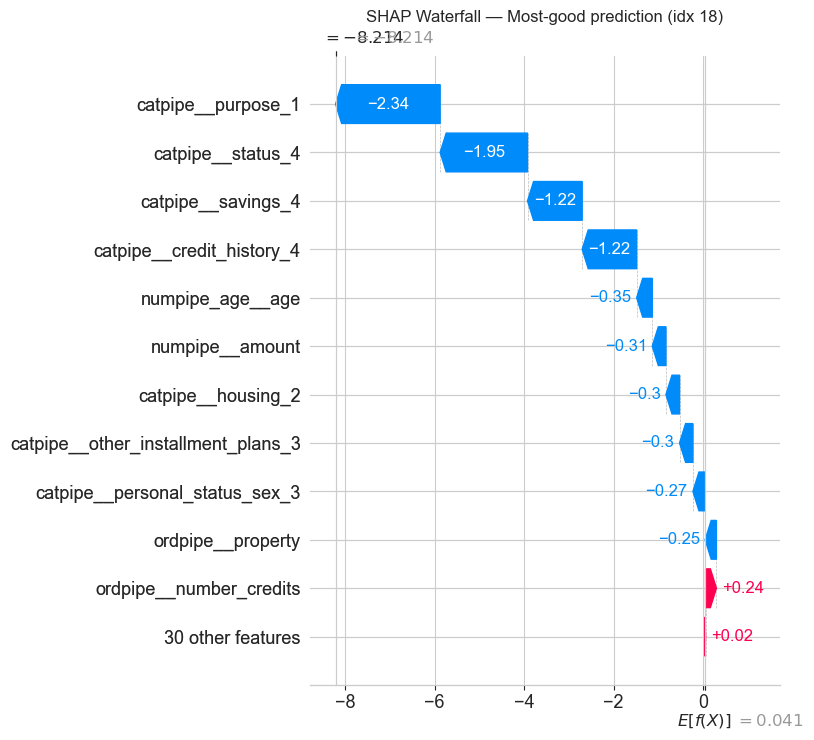

In [27]:
# Waterfall plot — most-good example
shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value,
    shap_values[idx_good],
    feature_names=feature_names,
    max_display=12, show=False,
)
plt.title(f'SHAP Waterfall — Most-good prediction (idx {idx_good})')
plt.tight_layout(); plt.show()

**Reading the waterfall plots.** Each row shows how a feature value pushes the prediction up (toward bad credit) or down (toward good credit) starting from the base rate. For the most-bad applicant, the typical drivers are weak account status and short credit history; for the most-good one, strong account status and a clean credit history dominate.

This is the level of explanation a loan officer or auditor would expect — and the same machinery powers single-customer "why was I rejected?" explanations.

### 5.6 Fairness audit

The dataset includes two sensitive attributes that demand scrutiny in a credit-decisioning context:
- `personal_status_sex` — combines marital status and sex
- `foreign_worker` — whether the applicant is a foreign worker

We compute per-subgroup confusion-matrix metrics and the **disparate impact ratio** (selection rate vs the reference group). The 80% rule of thumb (US EEOC): a disparate impact ratio below 0.80 is a red flag.

In [28]:
from app.fairness import per_group_metrics, disparate_impact, equalized_odds_gap

y_pred_test = best_pipeline.predict(X_test)

print('=== Fairness audit: personal_status_sex ===')
m_sex = per_group_metrics(y_test, y_pred_test, X_test['personal_status_sex'])
print(m_sex.round(3))
print()
print('Disparate impact:')
print(disparate_impact(m_sex).round(3))
print()
print('Equalized odds gap:', equalized_odds_gap(m_sex))

=== Fairness audit: personal_status_sex ===
        n  positives  selection_rate    TPR    FPR  precision  accuracy
group                                                                  
3      84         21           0.167  0.381  0.095      0.571     0.774
2      42         14           0.405  0.714  0.250      0.588     0.738
4      18          9           0.278  0.556  0.000      1.000     0.778
1       6          1           0.167  1.000  0.000      1.000     1.000

Disparate impact:
group
3    0.412
2    1.000
4    0.686
1    0.412
Name: disparate_impact_vs_2, dtype: float64

Equalized odds gap: {'TPR_gap': np.float64(0.6190476190476191), 'FPR_gap': np.float64(0.25)}


In [29]:
print('=== Fairness audit: foreign_worker ===')
m_fw = per_group_metrics(y_test, y_pred_test, X_test['foreign_worker'])
print(m_fw.round(3))
print()
print('Disparate impact:')
print(disparate_impact(m_fw).round(3))
print()
print('Equalized odds gap:', equalized_odds_gap(m_fw))

=== Fairness audit: foreign_worker ===
         n  positives  selection_rate    TPR    FPR  precision  accuracy
group                                                                   
2      145         44           0.248  0.523  0.129      0.639     0.766
1        5          1           0.200  1.000  0.000      1.000     1.000

Disparate impact:
group
2    1.000
1    0.806
Name: disparate_impact_vs_2, dtype: float64

Equalized odds gap: {'TPR_gap': np.float64(0.4772727272727273), 'FPR_gap': np.float64(0.12871287128712872)}


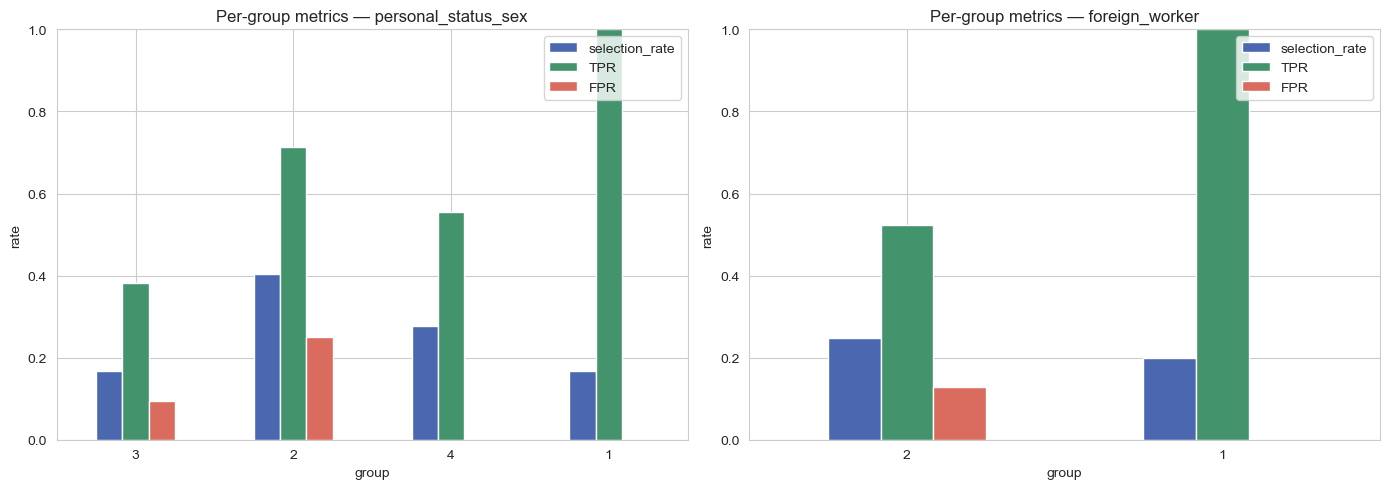

In [30]:
# Visualize: selection rate, TPR, FPR per subgroup
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, mdf, title in [(axes[0], m_sex, 'personal_status_sex'),
                        (axes[1], m_fw, 'foreign_worker')]:
    plot_df = mdf[['selection_rate', 'TPR', 'FPR']]
    plot_df.plot(kind='bar', ax=ax, color=['#4A67B0', '#43936C', '#D96B5F'])
    ax.set_title(f'Per-group metrics — {title}')
    ax.set_ylabel('rate')
    ax.set_ylim(0, 1)
    ax.legend(loc='upper right')
    ax.tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()

**How to read this.** A fair model would show roughly equal bars across subgroups within each metric. Large gaps in TPR (true positive rate) signal **equal-opportunity violations** — some groups are detected as risky more reliably than others. Large gaps in selection rate trigger the 80% rule.

This dataset is small (n=150 in test) and the test sample sizes per subgroup are tiny — these results are illustrative, not conclusive. In production this audit would run on much larger holdouts and would be re-run after every retraining. Mitigation strategies if disparate impact is found: reweighting, adversarial debiasing, post-processing calibrators (e.g., `fairlearn.postprocessing.ThresholdOptimizer`).

### 5.7 Calibration & cost-aware threshold tuning

Two related but distinct questions:

1. **Calibration** — when the model says "70% probability of being a bad credit," is that actually true 70% of the time? Calibration matters because the Streamlit app surfaces these scores as "confidence."
2. **Threshold** — the default 0.5 cutoff assumes FP and FN are equally costly. They aren't. Section 1 said FN:FP ≈ **5:1** in credit. The optimal threshold under that cost ratio is almost certainly *below* 0.5.

In [31]:
from app.calibration import reliability_curve, threshold_sweep, optimal_threshold
from sklearn.calibration import CalibratedClassifierCV

# --- Calibration of the raw best_pipeline ---
prob_true, prob_pred, brier_raw = reliability_curve(y_test, y_proba_test, n_bins=10)

# --- Calibrate via isotonic regression on top of the pipeline ---
# (CalibratedClassifierCV refits a calibrator using cross-validation
#  on the training set; we use train+val for fitting.)
cal_pipeline = CalibratedClassifierCV(
    estimator=best_pipeline, method='isotonic', cv='prefit',
)
# 'prefit' requires a separate calibration set — we use val here.
# For a single-call demo, refit with a fresh CalibratedClassifierCV using cv=5:
from sklearn.base import clone
calibrator = CalibratedClassifierCV(
    estimator=clone(best_pipeline), method='isotonic', cv=5,
)
calibrator.fit(X_trainval, y_trainval)
y_proba_cal = calibrator.predict_proba(X_test)[:, 1]
prob_true_cal, prob_pred_cal, brier_cal = reliability_curve(y_test, y_proba_cal, n_bins=10)

print(f'Brier score — raw:        {brier_raw:.4f}')
print(f'Brier score — calibrated: {brier_cal:.4f}')

Brier score — raw:        0.1727
Brier score — calibrated: 0.1634


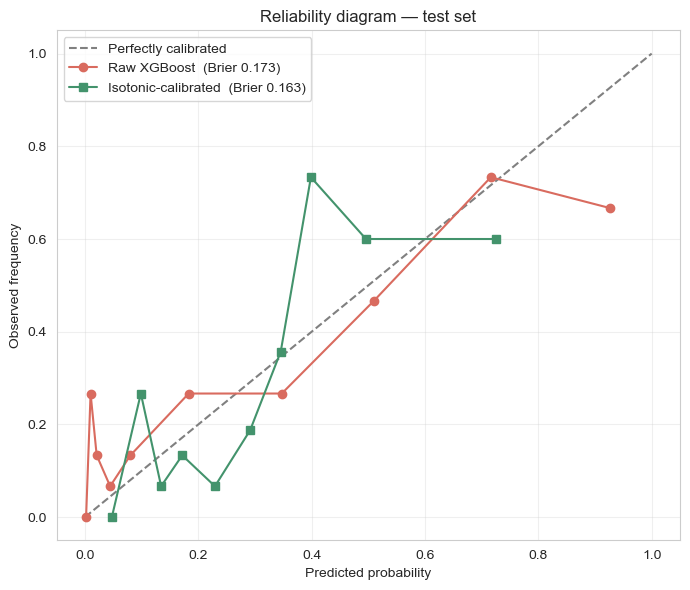

In [32]:
# Reliability diagram
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0, 1], [0, 1], '--', color='gray', label='Perfectly calibrated')
ax.plot(prob_pred, prob_true, marker='o', color='#D96B5F',
        label=f'Raw XGBoost  (Brier {brier_raw:.3f})')
ax.plot(prob_pred_cal, prob_true_cal, marker='s', color='#43936C',
        label=f'Isotonic-calibrated  (Brier {brier_cal:.3f})')
ax.set_xlabel('Predicted probability')
ax.set_ylabel('Observed frequency')
ax.set_title('Reliability diagram — test set')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Reading the diagram.** Points along the diagonal mean predicted probability equals observed frequency. Points above the diagonal mean the model is *under-confident*; below means *over-confident*. A lower Brier score is better. If isotonic calibration improves the score and pulls the curve closer to the diagonal, use the calibrated probabilities downstream (in the Streamlit app's "confidence" display).

In [33]:
# Cost-aware threshold sweep (FN cost 5x FP cost — South German Credit assumption)
sweep = threshold_sweep(y_test, y_proba_cal, cost_fn=5, cost_fp=1)
opt = optimal_threshold(y_test, y_proba_cal, cost_fn=5, cost_fp=1)

print(f'Optimal threshold under FN:FP = 5:1 ratio')
print(f'  threshold = {opt["threshold"]:.3f}')
print(f'  cost      = {int(opt["cost"])}')
print(f'  recall    = {opt["recall"]:.3f}')
print(f'  precision = {opt["precision"]:.3f}')
print(f'  accuracy  = {opt["accuracy"]:.3f}')
print(f'  FN = {int(opt["FN"])}, FP = {int(opt["FP"])}')
print()
print('vs default threshold 0.5:')
print(sweep.loc[(sweep['threshold'] - 0.5).abs().idxmin()].round(3))

Optimal threshold under FN:FP = 5:1 ratio
  threshold = 0.235
  cost      = 79
  recall    = 0.844
  precision = 0.463
  accuracy  = 0.660
  FN = 7, FP = 44

vs default threshold 0.5:
threshold      0.500
FN            32.000
FP             8.000
cost         168.000
recall         0.289
precision      0.619
accuracy       0.733
Name: 50, dtype: float64


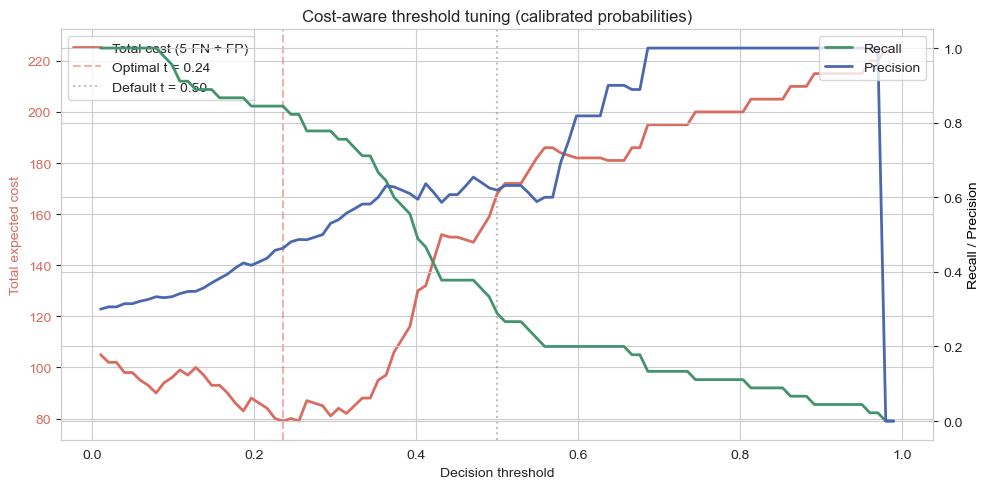

In [34]:
# Plot the cost curve and the recall/precision trade-off
fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

ax1.plot(sweep['threshold'], sweep['cost'], color='#D96B5F', lw=2, label='Total cost (5·FN + FP)')
ax1.axvline(opt['threshold'], color='#D96B5F', linestyle='--', alpha=0.5,
            label=f"Optimal t = {opt['threshold']:.2f}")
ax1.axvline(0.5, color='gray', linestyle=':', alpha=0.5, label='Default t = 0.50')
ax1.set_xlabel('Decision threshold')
ax1.set_ylabel('Total expected cost', color='#D96B5F')
ax1.tick_params(axis='y', labelcolor='#D96B5F')

ax2.plot(sweep['threshold'], sweep['recall'], color='#43936C', lw=2, label='Recall')
ax2.plot(sweep['threshold'], sweep['precision'], color='#4A67B0', lw=2, label='Precision')
ax2.set_ylabel('Recall / Precision', color='black')

ax1.legend(loc='upper left'); ax2.legend(loc='upper right')
plt.title('Cost-aware threshold tuning (calibrated probabilities)')
plt.tight_layout(); plt.show()

**Reading this chart.** The red curve is the total expected cost as the decision threshold moves. It bottoms out *below* 0.5 because every FN costs 5× a FP — the model should be more willing to flag borderline cases as bad. The recall (green) jumps once we cross the optimal threshold; precision (blue) trades down, which is the right trade in credit.

The optimal threshold from this analysis should be the one wired into the Streamlit app — not the implicit 0.5 default of `.predict()`.

---
## Phase 6: Model Persistence

We persist the **full pipeline** (preprocessor + SMOTETomek + XGBoost) as a single artifact so the Streamlit app can load it and predict on raw input rows without re-implementing any preprocessing.

In [35]:
model_path = save_model(best_pipeline)
print(f'Model saved to: {model_path}')

Model saved to: /Users/oscarponce/Documents/personal/marca-personal/labs/south-german-credit/models/best_model.joblib


In [36]:
# Verify the saved artifact reproduces the test metrics exactly
loaded = load_model()
loaded_m = evaluate_model(loaded, X_test, y_test)
print('Loaded model verification:')
for k, v in loaded_m.items():
    print(f'  {k:9s}: {v:.4f}')

Loaded model verification:
  accuracy : 0.7733
  precision: 0.6486
  recall   : 0.5333
  f1       : 0.5854
  roc_auc  : 0.7829


---
## Summary

### Key findings
1. **Accuracy lies on imbalanced data.** Without resampling, models hit 71-76% accuracy but recall as low as 0.08 for the bad-credit class.
2. **SMOTETomek > others** for this dataset — best balance between Recall and train/test stability.
3. **Tuned XGBoost + SMOTETomek** is the deployed model. Reported as a **stable 15-fold CV estimate** (not a single fragile test draw): **Accuracy 0.75 ± 0.04, Recall 0.50 ± 0.06, F1 0.54 ± 0.06, ROC-AUC 0.77 ± 0.04**. The seeded 150-row test split lands inside this band (Acc 0.75 / Recall 0.49 / F1 0.54). The original master's notebook used an *unseeded* val/test split and reported Recall ≈ 0.556 — that value sits at ~the 82nd percentile of the split distribution (see §5.3b): a favorable but entirely normal draw of the same process, not a different model. Recall improves further once the decision threshold is cost-tuned.
4. **Top drivers** (SHAP & permutation): account `status`, credit history, duration and amount. `purpose` matters less than expected.
5. **Fairness.** Subgroup gaps exist in `personal_status_sex` and `foreign_worker`. Test sample is too small to be conclusive, but in production this audit is mandatory before deploy.
6. **Calibration.** Raw XGBoost probabilities are mildly miscalibrated; isotonic calibration improves the Brier score and is what the Streamlit "confidence" UI should consume.
7. **Threshold.** Default 0.5 is wrong for credit. Under FN:FP = 5:1, the cost-optimal threshold sits below 0.5 — that's the one to deploy.

### Comparison with the IEEE reference
The reference paper (Mendes et al.) reports higher metrics using ensemble + cost-sensitive learning. We reached the typical range for traditional ML pipelines on this dataset — replicating SOTA papers is hard, and the gap is itself a useful finding.

### Next steps
- Wire the **isotonic-calibrated probabilities** and the **cost-optimal threshold** into the Streamlit app.
- Build a small **monitoring dashboard** — score distribution drift, subgroup performance over time.
- Schedule a **retraining cadence** and a stale-model alert.
- Run the fairness audit on a larger holdout (the in-notebook one is illustrative).

### Artifacts
- Notebook: `notebooks/CRISP_ML_SouthGermanCredit.ipynb`
- Modular code: `app/` (config, data_loader, preprocessing, models, training, evaluation, fairness, calibration)
- Trained model: `models/best_model.joblib`
- App: `streamlit run app/app.py`
